In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from statsbombpy import sb
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from mplsoccer import Pitch

In [3]:
competitions = sb.competitions()
competitions

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
70,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2024-02-12T14:45:05.702250,2021-06-13T16:17:31.694,None,2024-02-12T14:45:05.702250
71,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2025-07-28T14:19:20.467348,2025-07-29T16:03:07.355174,2025-07-29T16:03:07.355174,2025-07-28T14:19:20.467348
72,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2024-02-13T13:27:17.178263,2024-02-13T13:30:52.820588,2024-02-13T13:30:52.820588,2024-02-13T13:27:17.178263
73,72,107,International,Women's World Cup,female,False,True,2023,2025-07-14T10:07:06.620906,2025-07-14T10:10:27.224586,2025-07-14T10:10:27.224586,2025-07-14T10:07:06.620906


In [4]:
worldcup_2018 = competitions[
    (competitions["competition_name"] == "FIFA World Cup") &
    (competitions["season_name"] == "2018")
]

worldcup_2018

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
30,43,3,International,FIFA World Cup,male,False,True,2018,2024-06-12T07:38:19.345758,2021-06-13T16:17:31.694,None,2024-06-12T07:38:19.345758


In [6]:
matches = sb.matches(
    competition_id=43,
    season_id=3
)

matches.head()

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,7585,2018-07-03,20:00:00.000,International - FIFA World Cup,2018,Colombia,England,1,1,available,...,2021-06-13T16:17:31.694,4,Round of 16,Otkritie Bank Arena,Mark Geiger,José Néstor Pekerman,Gareth Southgate,1.0.2,None,None
1,7570,2018-06-28,20:00:00.000,International - FIFA World Cup,2018,England,Belgium,0,1,available,...,2021-06-13T16:17:31.694,3,Group Stage,Stadion Kaliningrad,Damir Skomina,Gareth Southgate,Roberto Martínez Montoliú,1.0.2,None,None
2,7586,2018-07-03,16:00:00.000,International - FIFA World Cup,2018,Sweden,Switzerland,1,0,available,...,2021-06-13T16:17:31.694,4,Round of 16,Saint-Petersburg Stadium,Damir Skomina,Jan Olof Andersson,Vladimir Petković,1.0.2,None,None
3,7557,2018-06-25,20:00:00.000,International - FIFA World Cup,2018,Iran,Portugal,1,1,available,...,2021-06-13T16:17:31.694,3,Group Stage,Mordovia Arena,Enrique Cáceres,Carlos Manuel Brito Leal Queiróz,Fernando Manuel Fernandes da Costa Santos,1.0.2,None,None
4,7542,2018-06-20,14:00:00.000,International - FIFA World Cup,2018,Portugal,Morocco,1,0,available,...,2021-06-13T16:17:31.694,2,Group Stage,Stadion Luzhniki,Mark Geiger,Fernando Manuel Fernandes da Costa Santos,Hervé Renard,1.0.2,None,None


In [7]:
final = matches[
    (
        ((matches["home_team"] == "France") & (matches["away_team"] == "Croatia")) |
        ((matches["home_team"] == "Croatia") & (matches["away_team"] == "France"))
    )
]

final

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
39,8658,2018-07-15,17:00:00.000,International - FIFA World Cup,2018,France,Croatia,4,2,available,...,2021-06-13T16:17:31.694,7,Final,Stadion Luzhniki,Néstor Fabián Pitana,Didier Deschamps,Zlatko Dalić,1.0.2,None,None


In [8]:
match_id = final.iloc[0]["match_id"]
match_id

np.int64(8658)

In [9]:
events = sb.events(match_id=match_id)

events.head()

,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,counterpress,dribble_outcome,dribble_overrun,duel_outcome,duel_type,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 442, 'lineup': [{'player': {'id'...",France,771,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Croatia,785,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,France,771,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Croatia,785,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Croatia,785,00:00:00.000,Half Start,NaN


In [10]:
events["player"].dropna().unique()

array(['Mario Mandžukić', 'Marcelo Brozović', 'Luka Modrić',
       'Šime Vrsaljko', 'Danijel Subašić', 'Raphaël Varane',
       'Ivan Perišić', 'Ivan Rakitić', 'Ivan Strinić', 'Domagoj Vida',
       'Dejan Lovren', 'Benjamin Pavard', "N''Golo Kanté",
       'Antoine Griezmann', 'Hugo Lloris', 'Samuel Yves Umtiti',
       'Blaise Matuidi', 'Olivier Giroud', 'Paul Pogba',
       'Kylian Mbappé Lottin', 'Ante Rebić', 'Lucas Hernández Pi',
       "Steven N''Kemboanza Mike Christopher Nzonzi", 'Corentin Tolisso',
       'Andrej Kramarić', 'Nabil Fekir', 'Marko Pjaca'], dtype=object)

In [11]:
def heatmap(events, player, team):

    df = events[
        (events["player"] == player) &
        (events["team"] == team) &
        (events["location"].notna())
    ].copy()

    df["x"] = df["location"].apply(lambda x: x[0])
    df["y"] = df["location"].apply(lambda x: x[1])

    cmap = LinearSegmentedColormap.from_list(
        "heat",
        ["#ffffff","#dbe7f5","#1457ff","#15d84a","#f3ef1b","#ff9200","#e10000"]
    )

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="white",
        line_color="#2b2b2b",
        linewidth=1.7
    )

    fig, ax = pitch.draw(figsize=(8,6))

    xgrid = np.linspace(0,120,600)
    ygrid = np.linspace(0,80,400)
    xx,yy = np.meshgrid(xgrid,ygrid)

    values = np.vstack([df["x"],df["y"]])
    kde = gaussian_kde(values)

    zz = kde(np.vstack([xx.ravel(),yy.ravel()])).reshape(xx.shape)
    zz = gaussian_filter(zz,3)
    zz = zz/np.max(zz)

    ax.imshow(
        zz,
        extent=[0,120,0,80],
        origin="lower",
        cmap=cmap,
        interpolation="bicubic",
        alpha=0.9
    )

    pitch.draw(ax=ax)

    ax.text(
        60,88,
        player,
        ha="center",
        fontsize=14,
        color="#69b7d0",
        fontweight="bold"
    )

    ax.text(
        60,85,
        f"{team} | {len(df)} Dokunuş",
        ha="center",
        fontsize=11,
        color="#69b7d0"
    )

    sm = ScalarMappable(norm=Normalize(vmin=0,vmax=1),cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm,ax=ax,fraction=0.035,pad=0.02)
    cbar.set_label("Yoğunluk")

    plt.show()

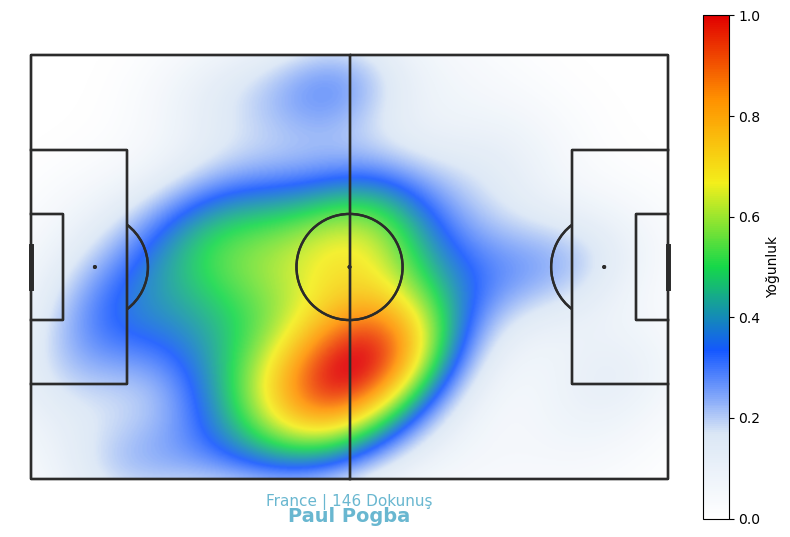

In [12]:
heatmap(events,"Paul Pogba","France")

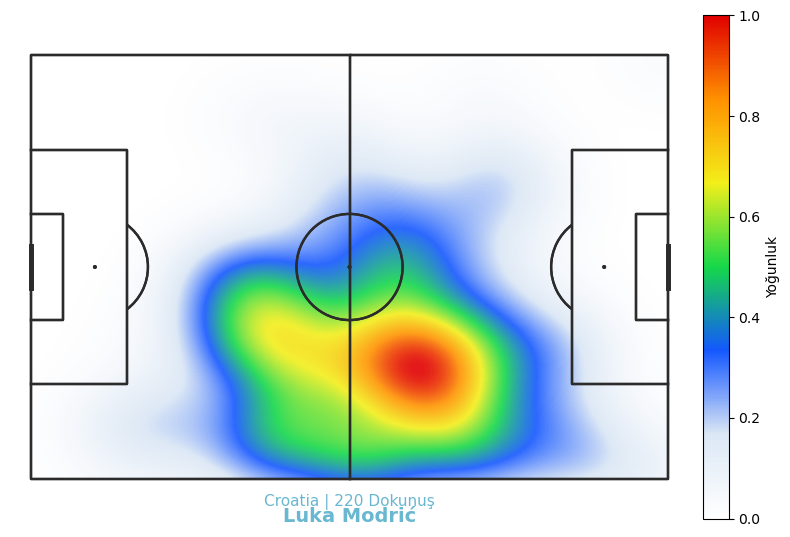

In [13]:
heatmap(events,"Luka Modrić","Croatia")

In [15]:
events["team"].dropna().unique()

array(['France', 'Croatia'], dtype=object)

In [16]:
events["type"].dropna().unique()

array(['Starting XI', 'Half Start', 'Pass', 'Ball Receipt*', 'Carry',
       'Pressure', 'Duel', 'Miscontrol', 'Clearance', 'Block',
       'Ball Recovery', 'Dispossessed', 'Foul Committed', 'Foul Won',
       'Camera On', 'Interception', 'Dribble', 'Camera off',
       'Injury Stoppage', 'Dribbled Past', 'Own Goal For',
       'Own Goal Against', 'Shot', 'Goal Keeper', 'Shield', 'Player Off',
       'Player On', 'Half End', 'Referee Ball-Drop', 'Substitution',
       'Error', 'Tactical Shift'], dtype=object)

In [17]:
def pass_heatmap(events, team_name, show_colorbar=True):
    df = events[
        (events["team"] == team_name) &
        (events["type"] == "Pass") &
        (events["location"].notna())
    ].copy()

    df["x"] = df["location"].apply(
        lambda loc: loc[0] if isinstance(loc, list) and len(loc) >= 2 else np.nan
    )
    df["y"] = df["location"].apply(
        lambda loc: loc[1] if isinstance(loc, list) and len(loc) >= 2 else np.nan
    )
    df = df.dropna(subset=["x", "y"])

    cmap = LinearSegmentedColormap.from_list(
        "custom_ref",
        [
            "#ffffff",
            "#dbe7f5",
            "#1457ff",
            "#15d84a",
            "#f3ef1b",
            "#ff9200",
            "#e10000",
        ],
        N=256
    )

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="white",
        line_color="#2b2b2b",
        linewidth=1.7,
        line_zorder=5
    )

    fig, ax = pitch.draw(figsize=(8.6, 6.3))

    xgrid = np.linspace(0, 120, 700)
    ygrid = np.linspace(0, 80, 500)
    xx, yy = np.meshgrid(xgrid, ygrid)

    values = np.vstack([df["x"], df["y"]])
    kde = gaussian_kde(values, bw_method=0.23)
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    zz = gaussian_filter(zz, sigma=3.0)
    zz = zz / np.nanmax(zz)

    fade_start = 0.14
    alpha = np.clip((zz - fade_start) / (1 - fade_start), 0, 1)
    alpha = alpha ** 1.7

    ax.imshow(
        zz,
        extent=[0, 120, 0, 80],
        origin="lower",
        cmap=cmap,
        interpolation="bicubic",
        alpha=alpha,
        aspect="auto",
        zorder=1
    )

    pitch.draw(ax=ax)

    ax.text(
        60, 89.0,
        team_name,
        ha="center", va="bottom",
        fontsize=15, color="#69b7d0", fontweight="bold"
    )
    ax.text(
        60, 85.7,
        f"Pas Yoğunluğu | {len(df)} Pas",
        ha="center", va="bottom",
        fontsize=12.5, color="#69b7d0", fontweight="bold"
    )

    if show_colorbar:
        sm = ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.025)
        cbar.set_label("Yoğunluk", fontsize=10)

    plt.tight_layout()
    plt.show()

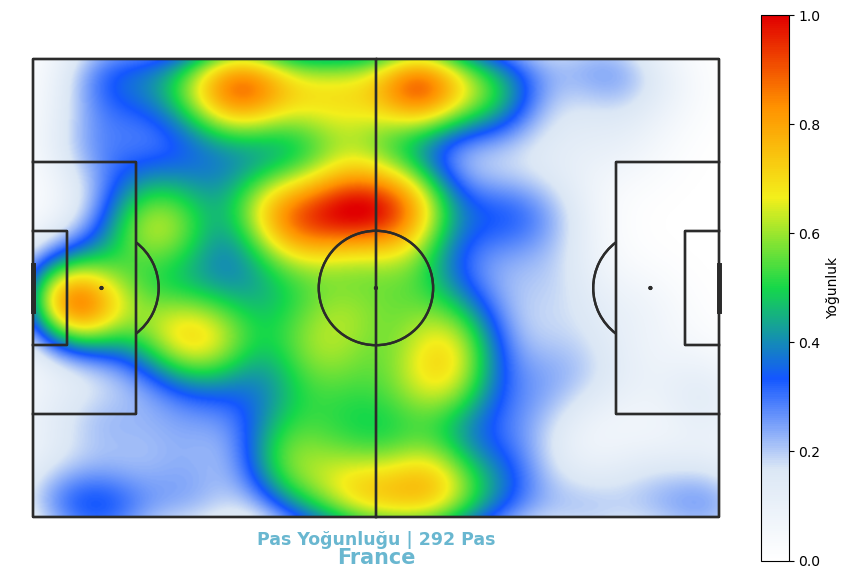

In [18]:
pass_heatmap(events, "France", show_colorbar=True)

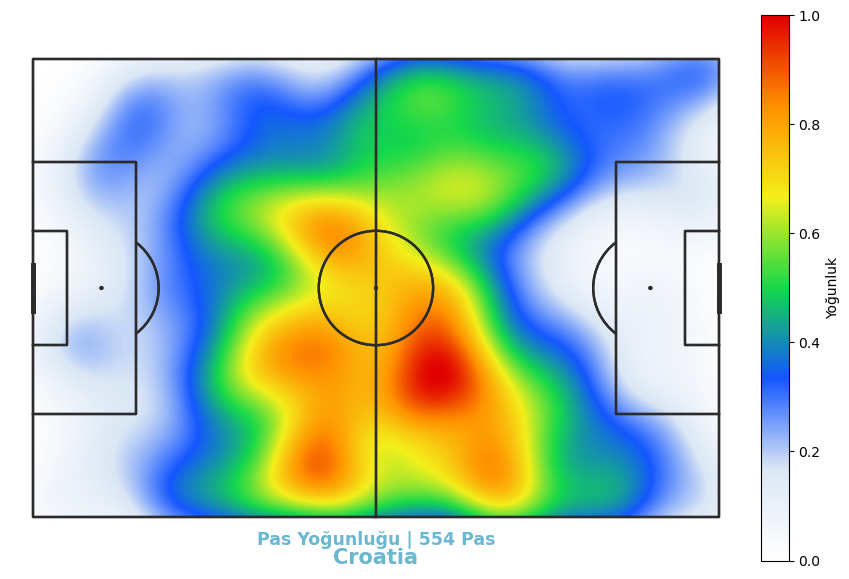

In [20]:
pass_heatmap(events, "Croatia", show_colorbar=True)

In [21]:
def shot_map(events, team_name):
    df = events[
        (events["team"] == team_name) &
        (events["type"] == "Shot") &
        (events["location"].notna())
    ].copy()

    df["x"] = df["location"].apply(
        lambda loc: loc[0] if isinstance(loc, list) and len(loc) >= 2 else np.nan
    )
    df["y"] = df["location"].apply(
        lambda loc: loc[1] if isinstance(loc, list) and len(loc) >= 2 else np.nan
    )

    if "shot_outcome" in df.columns:
        df["shot_result"] = df["shot_outcome"].astype(str)
    else:
        df["shot_result"] = "Unknown"

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="white",
        line_color="#2b2b2b",
        linewidth=1.7
    )

    fig, ax = pitch.draw(figsize=(8.6, 6.3))

    goal_df = df[df["shot_result"].str.contains("Goal", case=False, na=False)]
    non_goal_df = df[~df["shot_result"].str.contains("Goal", case=False, na=False)]

    ax.scatter(
        non_goal_df["x"],
        non_goal_df["y"],
        s=180,
        c="#1457ff",
        edgecolors="#2b2b2b",
        linewidths=1.2,
        alpha=0.9,
        zorder=3
    )

    ax.scatter(
        goal_df["x"],
        goal_df["y"],
        s=240,
        c="#e10000",
        edgecolors="#2b2b2b",
        linewidths=1.4,
        alpha=0.95,
        zorder=4
    )

    ax.text(
        60, 89.0,
        team_name,
        ha="center", va="bottom",
        fontsize=15, color="#69b7d0", fontweight="bold"
    )
    ax.text(
        60, 85.7,
        f"Şut Haritası | {len(df)} Şut",
        ha="center", va="bottom",
        fontsize=12.5, color="#69b7d0", fontweight="bold"
    )

    ax.scatter([], [], s=180, c="#1457ff", edgecolors="#2b2b2b", label="Şut")
    ax.scatter([], [], s=240, c="#e10000", edgecolors="#2b2b2b", label="Gol")
    ax.legend(loc="upper right", frameon=False, fontsize=10)

    plt.tight_layout()
    plt.show()

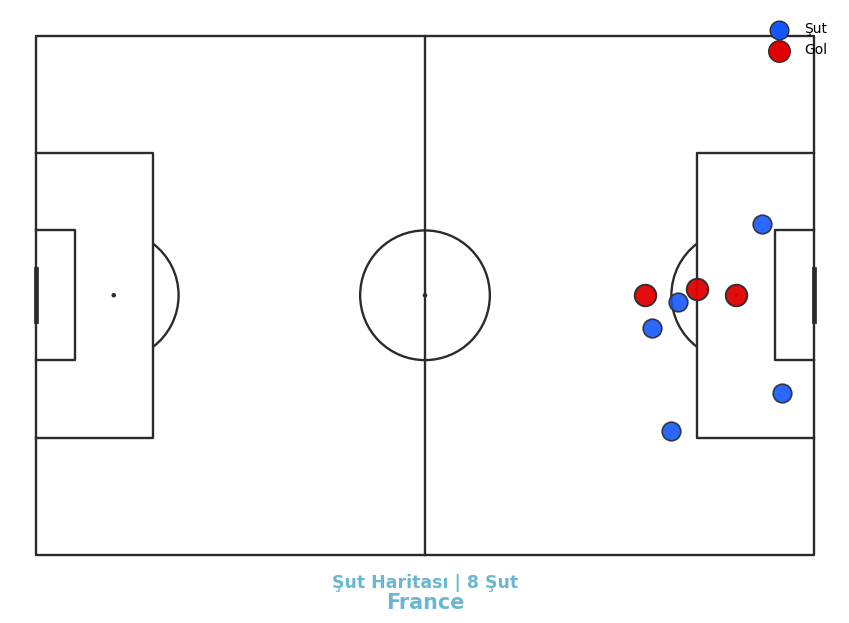

In [22]:
shot_map(events, "France")

In [23]:
events[
(events["type"]=="Shot")
][["team","player","shot_outcome"]]

,team,player,shot_outcome
2906,Croatia,Domagoj Vida,Off T
2907,Croatia,Ivan Rakitić,Off T
2908,Croatia,Ivan Perišić,Goal
2909,France,Antoine Griezmann,Goal
2910,Croatia,Ante Rebić,Wayward
2911,Croatia,Ivan Perišić,Blocked
2912,Croatia,Dejan Lovren,Blocked
2913,Croatia,Domagoj Vida,Off T
2914,France,Antoine Griezmann,Saved
2915,Croatia,Ante Rebić,Saved


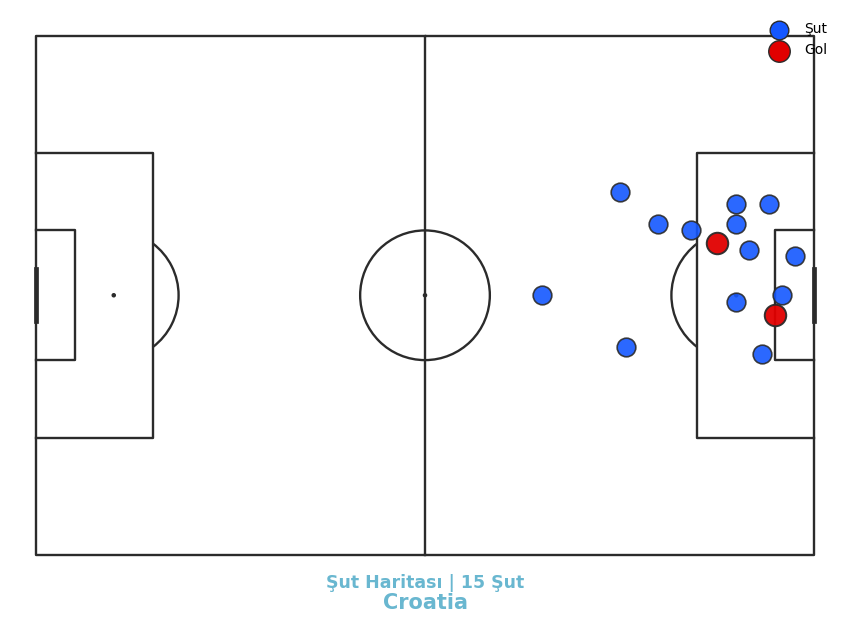

In [24]:
shot_map(events, "Croatia")

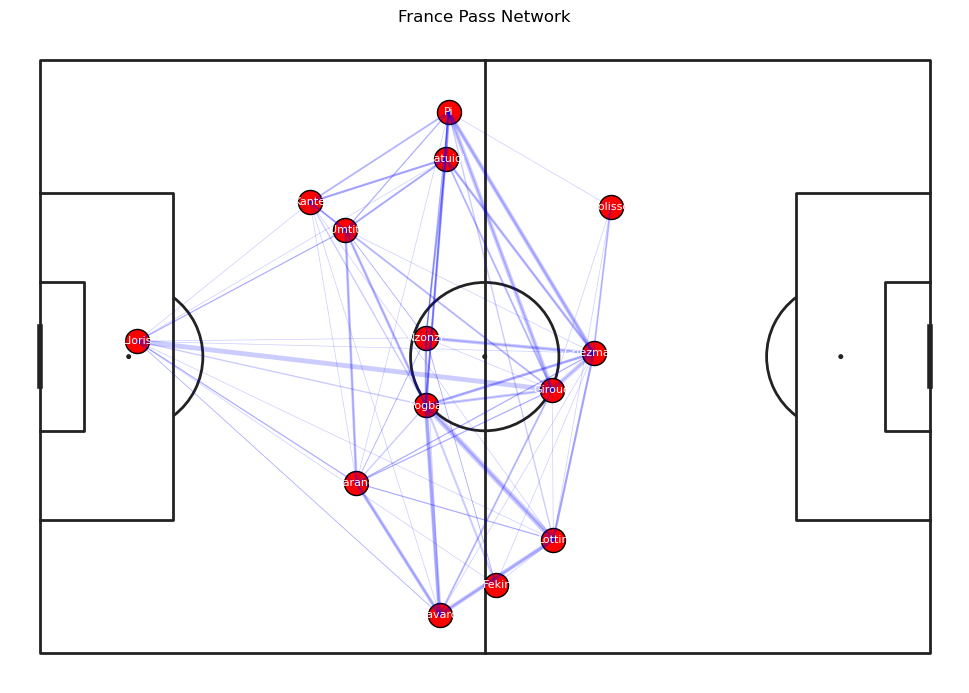

In [25]:
import pandas as pd
from mplsoccer import Pitch
import matplotlib.pyplot as plt

passes = events[
    (events["team"] == "France") &
    (events["type"] == "Pass")
].copy()

passes["x"] = passes["location"].apply(lambda x: x[0] if isinstance(x,list) else None)
passes["y"] = passes["location"].apply(lambda x: x[1] if isinstance(x,list) else None)

passes["end_x"] = passes["pass_end_location"].apply(lambda x: x[0] if isinstance(x,list) else None)
passes["end_y"] = passes["pass_end_location"].apply(lambda x: x[1] if isinstance(x,list) else None)

passes = passes.dropna(subset=["x","y","end_x","end_y"])

avg_locs = passes.groupby("player")[["x","y"]].mean()

pass_counts = passes.groupby(["player","pass_recipient"]).size().reset_index(name="count")

pitch = Pitch(pitch_type="statsbomb", pitch_color="white", line_color="#222")
fig, ax = pitch.draw(figsize=(10,7))

for i,row in pass_counts.iterrows():
    
    if row["player"] in avg_locs.index and row["pass_recipient"] in avg_locs.index:
        
        x1,y1 = avg_locs.loc[row["player"]]
        x2,y2 = avg_locs.loc[row["pass_recipient"]]

        ax.plot([x1,x2],[y1,y2], color="blue", alpha=0.2, linewidth=row["count"]/2)

for player,(x,y) in avg_locs.iterrows():
    
    ax.scatter(x,y,s=300,color="red",edgecolor="black")
    
    ax.text(x,y,player.split()[-1],ha="center",va="center",fontsize=8,color="white")

plt.title("France Pass Network")
plt.show()

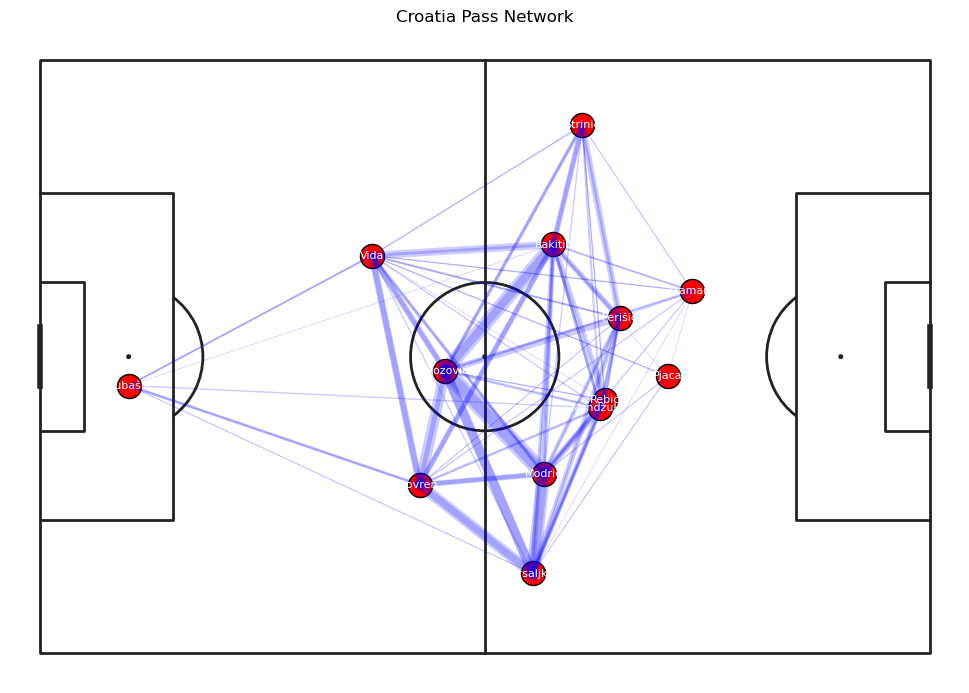

In [32]:
passes = events[
    (events["team"] == "Croatia") &
    (events["type"] == "Pass")
].copy()

passes["x"] = passes["location"].apply(lambda x: x[0] if isinstance(x, list) else None)
passes["y"] = passes["location"].apply(lambda x: x[1] if isinstance(x, list) else None)

passes["end_x"] = passes["pass_end_location"].apply(lambda x: x[0] if isinstance(x, list) else None)
passes["end_y"] = passes["pass_end_location"].apply(lambda x: x[1] if isinstance(x, list) else None)

passes = passes.dropna(subset=["x", "y", "end_x", "end_y"])

avg_locs = passes.groupby("player")[["x", "y"]].mean()

pass_counts = passes.groupby(["player", "pass_recipient"]).size().reset_index(name="count")

pitch = Pitch(pitch_type="statsbomb", pitch_color="white", line_color="#222")
fig, ax = pitch.draw(figsize=(10, 7))

for _, row in pass_counts.iterrows():
    if row["player"] in avg_locs.index and row["pass_recipient"] in avg_locs.index:
        x1, y1 = avg_locs.loc[row["player"]]
        x2, y2 = avg_locs.loc[row["pass_recipient"]]
        ax.plot([x1, x2], [y1, y2], color="blue", alpha=0.2, linewidth=row["count"] / 2)

for player, (x, y) in avg_locs.iterrows():
    ax.scatter(x, y, s=300, color="red", edgecolor="black")
    ax.text(x, y, player.split()[-1], ha="center", va="center", fontsize=8, color="white")

plt.title("Croatia Pass Network")
plt.show()